In [ ]:
!nvidia-smi

Wed May 27 16:12:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [ ]:
import os

base_dir = "/content/proyecto_ppe_yolo"

folders = [
    "dataset",
    "notebooks",
    "resultados",
    "resultados/predicciones",
    "resultados/metricas",
    "resultados/ejemplos",
    "informe"
]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

print("Carpetas creadas correctamente")

Carpetas creadas correctamente


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="lxN0r144V4FwUNthKDVY")
project = rf.workspace("marina-wgvsb").project("safety-helmet-detection-apiwd")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to safety-helmet-detection-1 in yolov8:: 100%|██████████| 27831/27831 [00:05<00:00, 5001.01it/s]


In [ ]:
dataset_dir = "/content/safety-helmet-detection-1"
data_yaml = f"{dataset_dir}/data.yaml"

with open(data_yaml, "r") as f:
    print(f.read())

names:
- head
- helmet
- person
nc: 3
roboflow:
  license: CC BY 4.0
  project: safety-helmet-detection-apiwd
  url: https://universe.roboflow.com/marina-wgvsb/safety-helmet-detection-apiwd/dataset/1
  version: 1
  workspace: marina-wgvsb
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
data_colab = """
train: /content/safety-helmet-detection-1/train/images
val: /content/safety-helmet-detection-1/valid/images
test: /content/safety-helmet-detection-1/test/images

nc: 3
names: ['head', 'helmet', 'person']
"""

with open("/content/safety-helmet-detection-1/data_colab.yaml", "w") as f:
    f.write(data_colab)

print("data_colab.yaml creado correctamente")

data_colab.yaml creado correctamente


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/safety-helmet-detection-1/data_colab.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="pmv_casco_yolov8n"
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/safety-helmet-detection-1/data_colab.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pmv_casco_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/pmv_casco_yolov8n/weights/best.pt")

test_metrics = model.val(
    data="/content/safety-helmet-detection-1/data_colab.yaml",
    split="test",
    name="evaluacion_test_pmv"
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1519.4±169.4 MB/s, size: 54.9 KB)
val: Scanning /content/safety-helmet-detection-1/test/labels... 610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 610/610 2.0Kit/s 0.3s
val: New cache created: /content/safety-helmet-detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.3it/s 9.0s
                   all        610       3141      0.707      0.653       0.68      0.408
                  head        122        780      0.875      0.859       0.89      0.543
                helmet        559       2259       0.93      0.885      0.946      0.587
                person         19        102      0.318      0.216      0.202     0.0932
Speed: 1.9ms preprocess, 4.1ms inference, 0.0ms los

In [ ]:
model.predict(
    source="/content/safety-helmet-detection-1/test/images",
    conf=0.25,
    save=True,
    name="predicciones_test_pmv"
)


image 1/610 /content/safety-helmet-detection-1/test/images/hard_hat_workers1000_png.rf.43d47261068c4bfddb0c0bbe03977f13.jpg: 640x640 3 helmets, 11.4ms
image 2/610 /content/safety-helmet-detection-1/test/images/hard_hat_workers1003_png.rf.651475a089543217c9097a421a8e2dce.jpg: 640x640 6 helmets, 7.3ms
image 3/610 /content/safety-helmet-detection-1/test/images/hard_hat_workers1007_png.rf.534504512ed529ae9a398e5ede2902f4.jpg: 640x640 3 helmets, 1 person, 7.3ms
image 4/610 /content/safety-helmet-detection-1/test/images/hard_hat_workers100_png.rf.a06f5d29368eedc1eee7518792be7146.jpg: 640x640 5 helmets, 7.2ms
image 5/610 /content/safety-helmet-detection-1/test/images/hard_hat_workers1012_png.rf.0ecfbf2a8507db21634901d815b2e1f3.jpg: 640x640 5 helmets, 7.2ms
image 6/610 /content/safety-helmet-detection-1/test/images/hard_hat_workers1013_png.rf.904be1d82b68c763ada4c26464935d4b.jpg: 640x640 6 heads, 4 helmets, 7.2ms
image 7/610 /content/safety-helmet-detection-1/test/images/hard_hat_workers1019_

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'head', 1: 'helmet', 2: 'person'}
 obb: None
 orig_img: array([[[  8,  14,  27],
         [  5,  11,  24],
         [  2,   8,  21],
         ...,
         [ 13,  65, 141],
         [ 18,  67, 143],
         [ 19,  68, 144]],
 
        [[  5,  11,  24],
         [  2,   8,  21],
         [  0,   5,  18],
         ...,
         [ 13,  65, 141],
         [ 17,  67, 143],
         [ 19,  68, 144]],
 
        [[  3,   6,  20],
         [  1,   4,  18],
         [  0,   2,  16],
         ...,
         [ 14,  66, 143],
         [ 18,  67, 145],
         [ 19,  68, 146]],
 
        ...,
 
        [[  0,  13,  36],
         [  1,  15,  38],
         [  1,  17,  40],
         ...,
         [ 18,  14,  19],
         [ 27,  21,  26],
         [ 30,  24,  29]],
 
        [[  0,  10,  36],
         [  0,  13,  36],
         [  0,  16,  39],
        

Cantidad de imágenes con predicciones: 610
Primeras imágenes: ['hard_hat_workers692_png.rf.259d3952f164d40fed4b1d97b484bc0d.jpg', 'hard_hat_workers3835_png.rf.ea98918d1b170f848a1d9c9692dcd542.jpg', 'hard_hat_workers3251_png.rf.833322167ade5749f8defff99361bff4.jpg', 'hard_hat_workers1189_png.rf.d8f4c44f526636cd71bc1b25a49adf66.jpg', 'hard_hat_workers1062_png.rf.b3d4526d73c0316e99f58b3b03540d02.jpg', 'hard_hat_workers3653_png.rf.5700479b84f1016fe510e38cefe04d87.jpg', 'hard_hat_workers2119_png.rf.e98edcdd371ac09c3a40610e8e2dc7f1.jpg', 'hard_hat_workers2126_png.rf.ba1ec4dd878f133dd842d2116df88d51.jpg', 'hard_hat_workers2864_png.rf.0d8691d899a67586d1e6e7e450dad322.jpg', 'hard_hat_workers2645_png.rf.6b732997e7ab04883847282bc8aaab19.jpg']


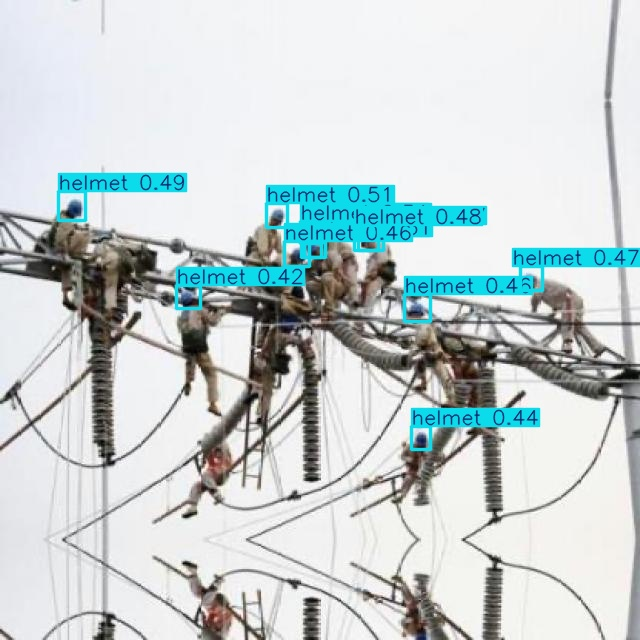

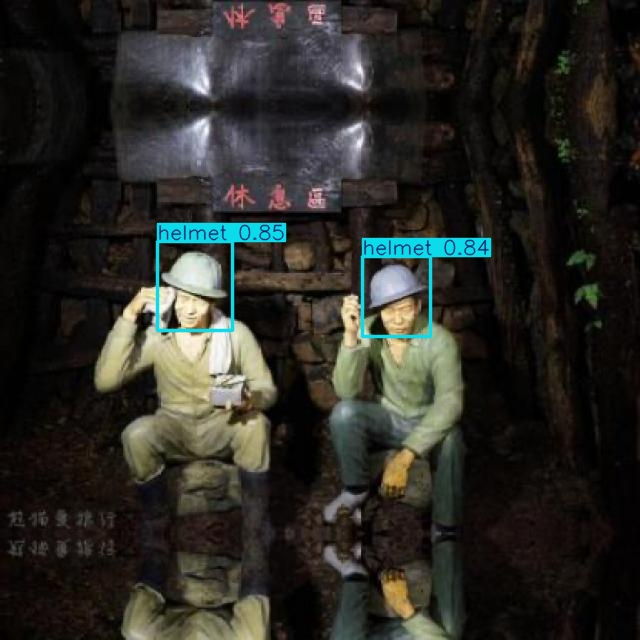

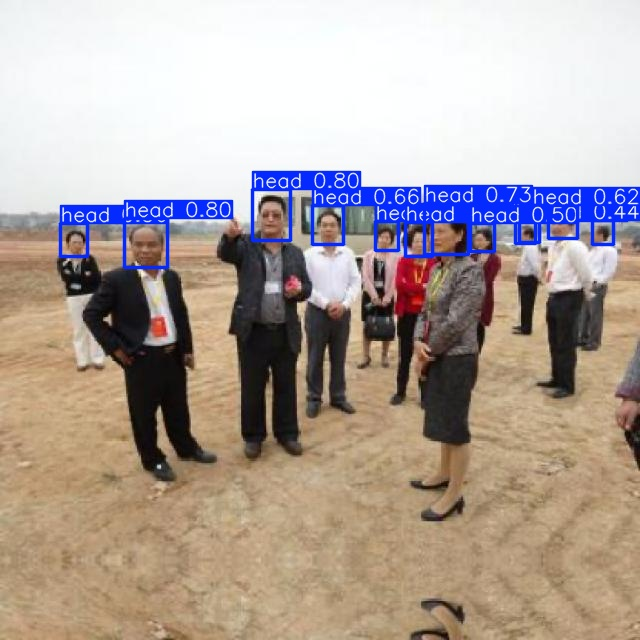

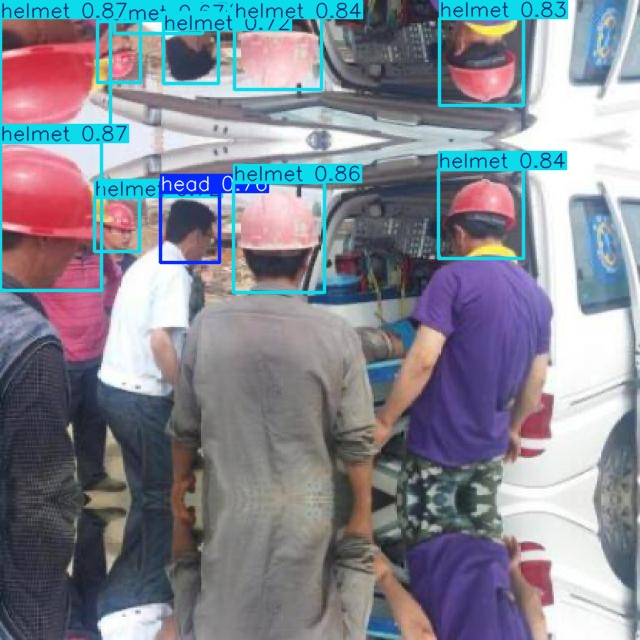

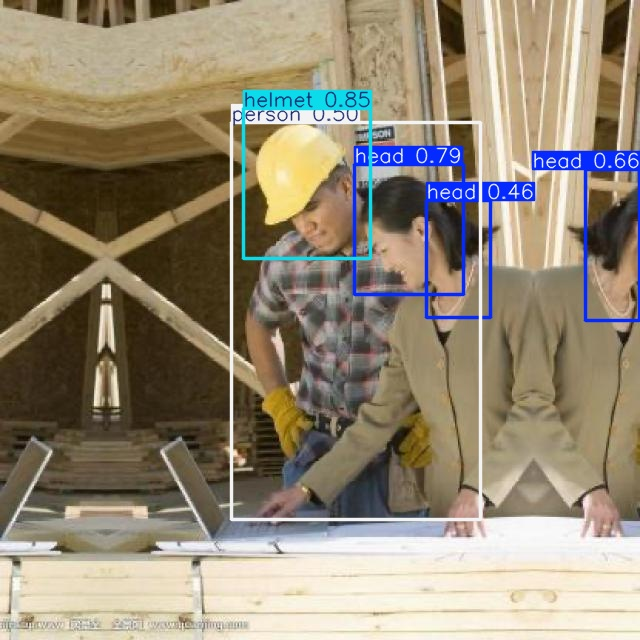

In [ ]:
import os
from IPython.display import Image, display

pred_dir = "/content/runs/detect/predicciones_test_pmv"

imagenes = [f for f in os.listdir(pred_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

print("Cantidad de imágenes con predicciones:", len(imagenes))
print("Primeras imágenes:", imagenes[:10])

for img in imagenes[:5]:
    display(Image(filename=os.path.join(pred_dir, img), width=500))

In [ ]:
import os
import shutil

pred_dir = "/content/runs/detect/predicciones_test_pmv"
dest_dir = "/content/proyecto_ppe_yolo/resultados/ejemplos_predicciones"

os.makedirs(dest_dir, exist_ok=True)

imagenes = [f for f in os.listdir(pred_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

# Copiamos las primeras 10 predicciones como ejemplos iniciales
for img in imagenes[:10]:
    shutil.copy(
        os.path.join(pred_dir, img),
        os.path.join(dest_dir, img)
    )

print("Ejemplos copiados a:", dest_dir)
print("Cantidad copiada:", len(os.listdir(dest_dir)))

Ejemplos copiados a: /content/proyecto_ppe_yolo/resultados/ejemplos_predicciones
Cantidad copiada: 10


**cumplimiento de casco**

Si hay helmets y no hay heads → cumple

Si hay heads y no hay helmets → no cumple

Si hay helmets y heads → cumplimiento parcial / revisar

Si no hay detecciones → incierto

aplicar el verificador a predicciones reales

In [ ]:
# ============================================================
# VERIFICADOR DE CUMPLIMIENTO DE CASCO
# ============================================================

import os
from ultralytics import YOLO

# 1. Cargar el modelo entrenado
# Este es el mejor modelo que salió del entrenamiento YOLOv8.
model = YOLO("/content/runs/detect/pmv_casco_yolov8n/weights/best.pt")


# 2. Función para obtener las clases detectadas por YOLO
# Recibe el resultado de una predicción y devuelve una lista como:
# ['helmet', 'helmet', 'head', 'person']
def obtener_clases_detectadas(resultado):
    clases = []
    nombres = resultado.names

    for cls_id in resultado.boxes.cls:
        clase = nombres[int(cls_id)]
        clases.append(clase)

    return clases


# 3. Función mejorada de cumplimiento
# Esta versión evalúa la escena completa, no trabajador por trabajador.
# Es decir, clasifica la imagen como:
# - "cumple" si solo se detectan cascos.
# - "no cumple" si solo se detectan cabezas sin casco.
# - "cumplimiento parcial / revisar" si aparecen cascos y cabezas.
# - "incierto" si no hay suficiente evidencia.
def verificar_cumplimiento_casco(clases_detectadas):
    num_cascos = clases_detectadas.count("helmet")
    num_cabezas = clases_detectadas.count("head")

    if num_cascos > 0 and num_cabezas == 0:
        estado = "cumple"

    elif num_cascos == 0 and num_cabezas > 0:
        estado = "no cumple"

    elif num_cascos > 0 and num_cabezas > 0:
        estado = "cumplimiento parcial / revisar"

    else:
        estado = "incierto"

    return estado


# 4. Preparar las imágenes del conjunto de prueba
test_dir = "/content/safety-helmet-detection-1/test/images"

imagenes_test = [
    os.path.join(test_dir, f)
    for f in os.listdir(test_dir)
    if f.endswith((".jpg", ".png", ".jpeg"))
]

print("Cantidad de imágenes de prueba encontradas:", len(imagenes_test))


# 5. Probar el verificador con las primeras 10 imágenes
# Para cada imagen:
# - YOLO detecta objetos.
# - Extraemos las clases.
# - Aplicamos la regla de cumplimiento.
for img_path in imagenes_test[:10]:
    resultado = model(img_path, conf=0.25, verbose=False)[0]
    clases_detectadas = obtener_clases_detectadas(resultado)
    estado = verificar_cumplimiento_casco(clases_detectadas)

    print("Imagen:", os.path.basename(img_path))
    print("Clases detectadas:", clases_detectadas)
    print("Número de cascos detectados:", clases_detectadas.count("helmet"))
    print("Número de cabezas detectadas:", clases_detectadas.count("head"))
    print("Estado de cumplimiento:", estado)
    print("-" * 70)

Cantidad de imágenes de prueba encontradas: 610
Imagen: hard_hat_workers692_png.rf.259d3952f164d40fed4b1d97b484bc0d.jpg
Clases detectadas: ['helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet', 'helmet']
Número de cascos detectados: 13
Número de cabezas detectadas: 0
Estado de cumplimiento: cumple
----------------------------------------------------------------------
Imagen: hard_hat_workers3835_png.rf.ea98918d1b170f848a1d9c9692dcd542.jpg
Clases detectadas: ['helmet', 'helmet']
Número de cascos detectados: 2
Número de cabezas detectadas: 0
Estado de cumplimiento: cumple
----------------------------------------------------------------------
Imagen: hard_hat_workers3251_png.rf.833322167ade5749f8defff99361bff4.jpg
Clases detectadas: ['head', 'head', 'head', 'head', 'head', 'head', 'head', 'head', 'head', 'head', 'head', 'head']
Número de cascos detectados: 0
Número de cabezas detectadas: 12
Estado de cumplimiento: no cumple

mostrar imágenes con la nueva clasificación

Imagen: hard_hat_workers692_png.rf.259d3952f164d40fed4b1d97b484bc0d.jpg
Cascos detectados: 13
Cabezas detectadas: 0
Estado de cumplimiento: cumple


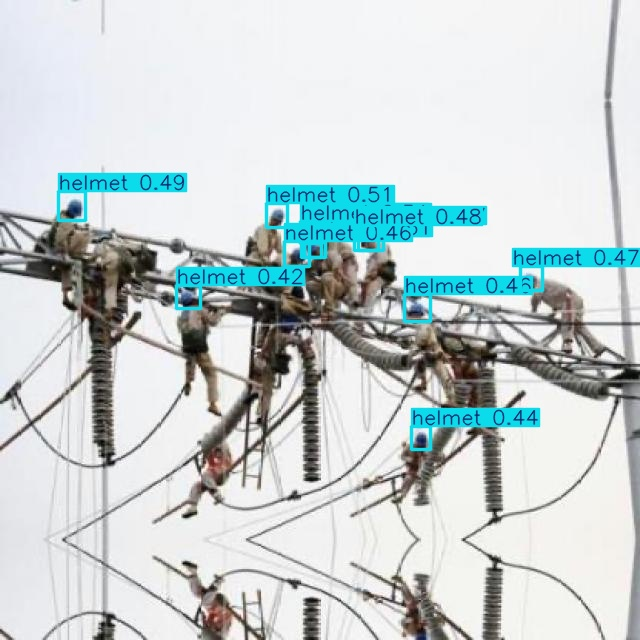

--------------------------------------------------------------------------------
Imagen: hard_hat_workers3835_png.rf.ea98918d1b170f848a1d9c9692dcd542.jpg
Cascos detectados: 2
Cabezas detectadas: 0
Estado de cumplimiento: cumple


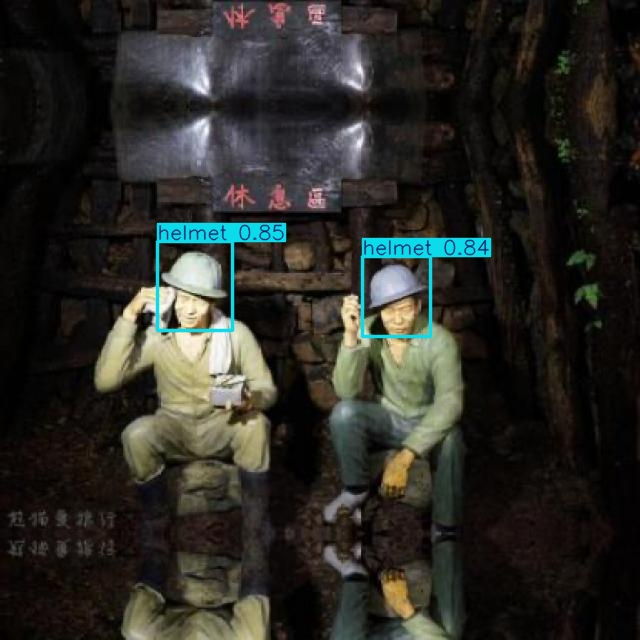

--------------------------------------------------------------------------------
Imagen: hard_hat_workers3251_png.rf.833322167ade5749f8defff99361bff4.jpg
Cascos detectados: 0
Cabezas detectadas: 12
Estado de cumplimiento: no cumple


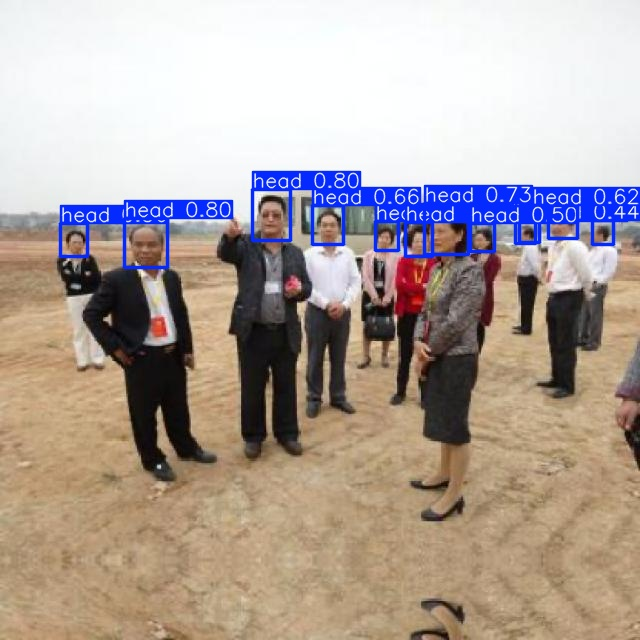

--------------------------------------------------------------------------------
Imagen: hard_hat_workers1189_png.rf.d8f4c44f526636cd71bc1b25a49adf66.jpg
Cascos detectados: 10
Cabezas detectadas: 1
Estado de cumplimiento: cumplimiento parcial / revisar


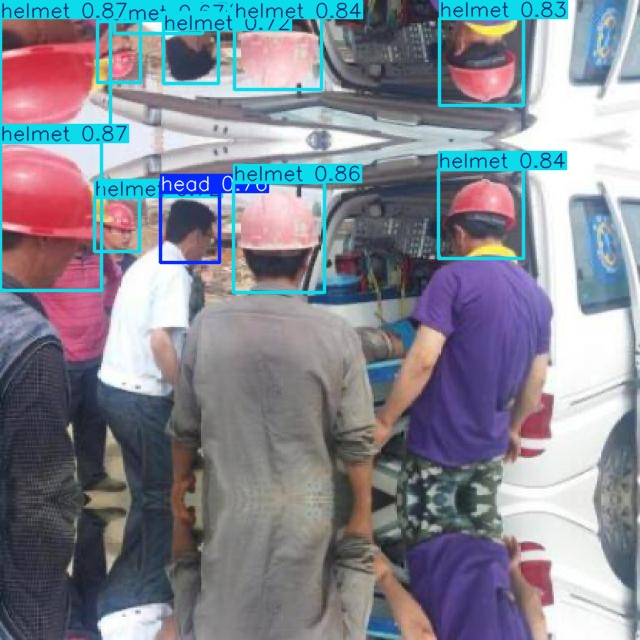

--------------------------------------------------------------------------------
Imagen: hard_hat_workers1062_png.rf.b3d4526d73c0316e99f58b3b03540d02.jpg
Cascos detectados: 1
Cabezas detectadas: 3
Estado de cumplimiento: cumplimiento parcial / revisar


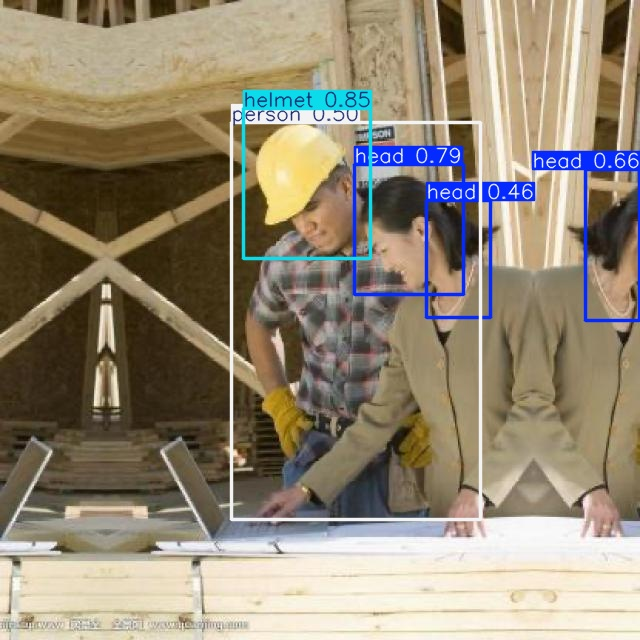

--------------------------------------------------------------------------------


In [ ]:
# ============================================================
# VISUALIZACIÓN DE PREDICCIONES + ESTADO DE CUMPLIMIENTO
# ============================================================

from IPython.display import Image, display
import os

# Carpeta donde YOLO guardó las imágenes con bounding boxes
pred_dir = "/content/runs/detect/predicciones_test_pmv"

# Mostramos las primeras 5 imágenes con su estado calculado
for img_path in imagenes_test[:5]:
    resultado = model(img_path, conf=0.25, verbose=False)[0]
    clases_detectadas = obtener_clases_detectadas(resultado)
    estado = verificar_cumplimiento_casco(clases_detectadas)

    nombre_img = os.path.basename(img_path)
    pred_img_path = os.path.join(pred_dir, nombre_img)

    print("Imagen:", nombre_img)
    print("Cascos detectados:", clases_detectadas.count("helmet"))
    print("Cabezas detectadas:", clases_detectadas.count("head"))
    print("Estado de cumplimiento:", estado)

    if os.path.exists(pred_img_path):
        display(Image(filename=pred_img_path, width=500))
    else:
        print("No se encontró la imagen con predicciones guardada.")

    print("-" * 80)

In [ ]:
# ============================================================
# GUARDAR RESULTADOS DEL VERIFICADOR EN CSV
# ============================================================

import pandas as pd
import os

resultados_verificador = []

# Aplicamos el verificador a todas las imágenes del conjunto test
for img_path in imagenes_test:
    resultado = model(img_path, conf=0.25, verbose=False)[0]
    clases_detectadas = obtener_clases_detectadas(resultado)
    estado = verificar_cumplimiento_casco(clases_detectadas)

    resultados_verificador.append({
        "imagen": os.path.basename(img_path),
        "num_cascos_detectados": clases_detectadas.count("helmet"),
        "num_cabezas_detectadas": clases_detectadas.count("head"),
        "num_personas_detectadas": clases_detectadas.count("person"),
        "estado_cumplimiento": estado
    })

df_verificador = pd.DataFrame(resultados_verificador)

csv_path = "/content/proyecto_ppe_yolo/resultados/metricas/resultados_verificador.csv"
df_verificador.to_csv(csv_path, index=False)

print("CSV guardado en:", csv_path)
df_verificador.head(10)

CSV guardado en: /content/proyecto_ppe_yolo/resultados/metricas/resultados_verificador.csv


,imagen,num_cascos_detectados,num_cabezas_detectadas,num_personas_detectadas,estado_cumplimiento
0,hard_hat_workers692_png.rf.259d3952f164d40fed4...,13,0,0,cumple
1,hard_hat_workers3835_png.rf.ea98918d1b170f848a...,2,0,0,cumple
2,hard_hat_workers3251_png.rf.833322167ade5749f8...,0,12,0,no cumple
3,hard_hat_workers1189_png.rf.d8f4c44f526636cd71...,10,1,0,cumplimiento parcial / revisar
4,hard_hat_workers1062_png.rf.b3d4526d73c0316e99...,1,3,1,cumplimiento parcial / revisar
5,hard_hat_workers3653_png.rf.5700479b84f1016fe5...,1,0,0,cumple
6,hard_hat_workers2119_png.rf.e98edcdd371ac09c3a...,3,0,0,cumple
7,hard_hat_workers2126_png.rf.ba1ec4dd878f133dd8...,5,4,0,cumplimiento parcial / revisar
8,hard_hat_workers2864_png.rf.0d8691d899a67586d1...,3,0,0,cumple
9,hard_hat_workers2645_png.rf.6b732997e7ab048838...,7,0,1,cumple


In [ ]:
# ============================================================
# RESUMEN DE ESTADOS DEL VERIFICADOR
# ============================================================

resumen_estados = df_verificador["estado_cumplimiento"].value_counts()

print("Resumen de estados de cumplimiento:")
print(resumen_estados)

print("\nPorcentaje de cada estado:")
print((resumen_estados / len(df_verificador) * 100).round(2))

Resumen de estados de cumplimiento:
estado_cumplimiento
cumple                            479
cumplimiento parcial / revisar     82
no cumple                          49
Name: count, dtype: int64

Porcentaje de cada estado:
estado_cumplimiento
cumple                            78.52
cumplimiento parcial / revisar    13.44
no cumple                          8.03
Name: count, dtype: float64


In [ ]:
# ============================================================
# GUARDAR RESUMEN DEL VERIFICADOR
# ============================================================

import pandas as pd

df_resumen = resumen_estados.reset_index()
df_resumen.columns = ["estado_cumplimiento", "cantidad"]

df_resumen["porcentaje"] = (df_resumen["cantidad"] / len(df_verificador) * 100).round(2)

resumen_csv_path = "/content/proyecto_ppe_yolo/resultados/metricas/resumen_verificador.csv"
df_resumen.to_csv(resumen_csv_path, index=False)

print("Resumen guardado en:", resumen_csv_path)
df_resumen

Resumen guardado en: /content/proyecto_ppe_yolo/resultados/metricas/resumen_verificador.csv


,estado_cumplimiento,cantidad,porcentaje
0,cumple,479,78.52
1,cumplimiento parcial / revisar,82,13.44
2,no cumple,49,8.03


In [ ]:
# ============================================================
# GUARDAR MÉTRICAS DEL MODELO EN TEST
# ============================================================

import pandas as pd

metricas_modelo = [
    {
        "clase": "all",
        "precision": 0.707,
        "recall": 0.653,
        "mAP_0.5": 0.700,
        "mAP_0.5_0.95": 0.408
    },
    {
        "clase": "head",
        "precision": 0.875,
        "recall": 0.859,
        "mAP_0.5": 0.890,
        "mAP_0.5_0.95": 0.543
    },
    {
        "clase": "helmet",
        "precision": 0.930,
        "recall": 0.885,
        "mAP_0.5": 0.946,
        "mAP_0.5_0.95": 0.587
    },
    {
        "clase": "person",
        "precision": 0.318,
        "recall": 0.216,
        "mAP_0.5": 0.202,
        "mAP_0.5_0.95": 0.0932
    }
]

df_metricas = pd.DataFrame(metricas_modelo)

metricas_csv_path = "/content/proyecto_ppe_yolo/resultados/metricas/metricas_modelo_test.csv"
df_metricas.to_csv(metricas_csv_path, index=False)

print("Métricas guardadas en:", metricas_csv_path)
df_metricas

Métricas guardadas en: /content/proyecto_ppe_yolo/resultados/metricas/metricas_modelo_test.csv


,clase,precision,recall,mAP_0.5,mAP_0.5_0.95
0,all,0.707,0.653,0.700,0.4080
1,head,0.875,0.859,0.890,0.5430
2,helmet,0.930,0.885,0.946,0.5870
3,person,0.318,0.216,0.202,0.0932


In [ ]:
# ============================================================
# COPIAR GRÁFICAS DEL ENTRENAMIENTO A RESULTADOS
# ============================================================

import os
import shutil

runs_dir = "/content/runs/detect/pmv_casco_yolov8n"
dest_graficas = "/content/proyecto_ppe_yolo/resultados/metricas/graficas_entrenamiento"

os.makedirs(dest_graficas, exist_ok=True)

archivos_graficas = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for archivo in archivos_graficas:
    origen = os.path.join(runs_dir, archivo)
    destino = os.path.join(dest_graficas, archivo)

    if os.path.exists(origen):
        shutil.copy(origen, destino)
        print("Copiado:", archivo)
    else:
        print("No encontrado:", archivo)

print("Gráficas guardadas en:", dest_graficas)

Copiado: results.png
Copiado: confusion_matrix.png
No encontrado: PR_curve.png
No encontrado: F1_curve.png
No encontrado: P_curve.png
No encontrado: R_curve.png
Gráficas guardadas en: /content/proyecto_ppe_yolo/resultados/metricas/graficas_entrenamiento


Mostrando: results.png


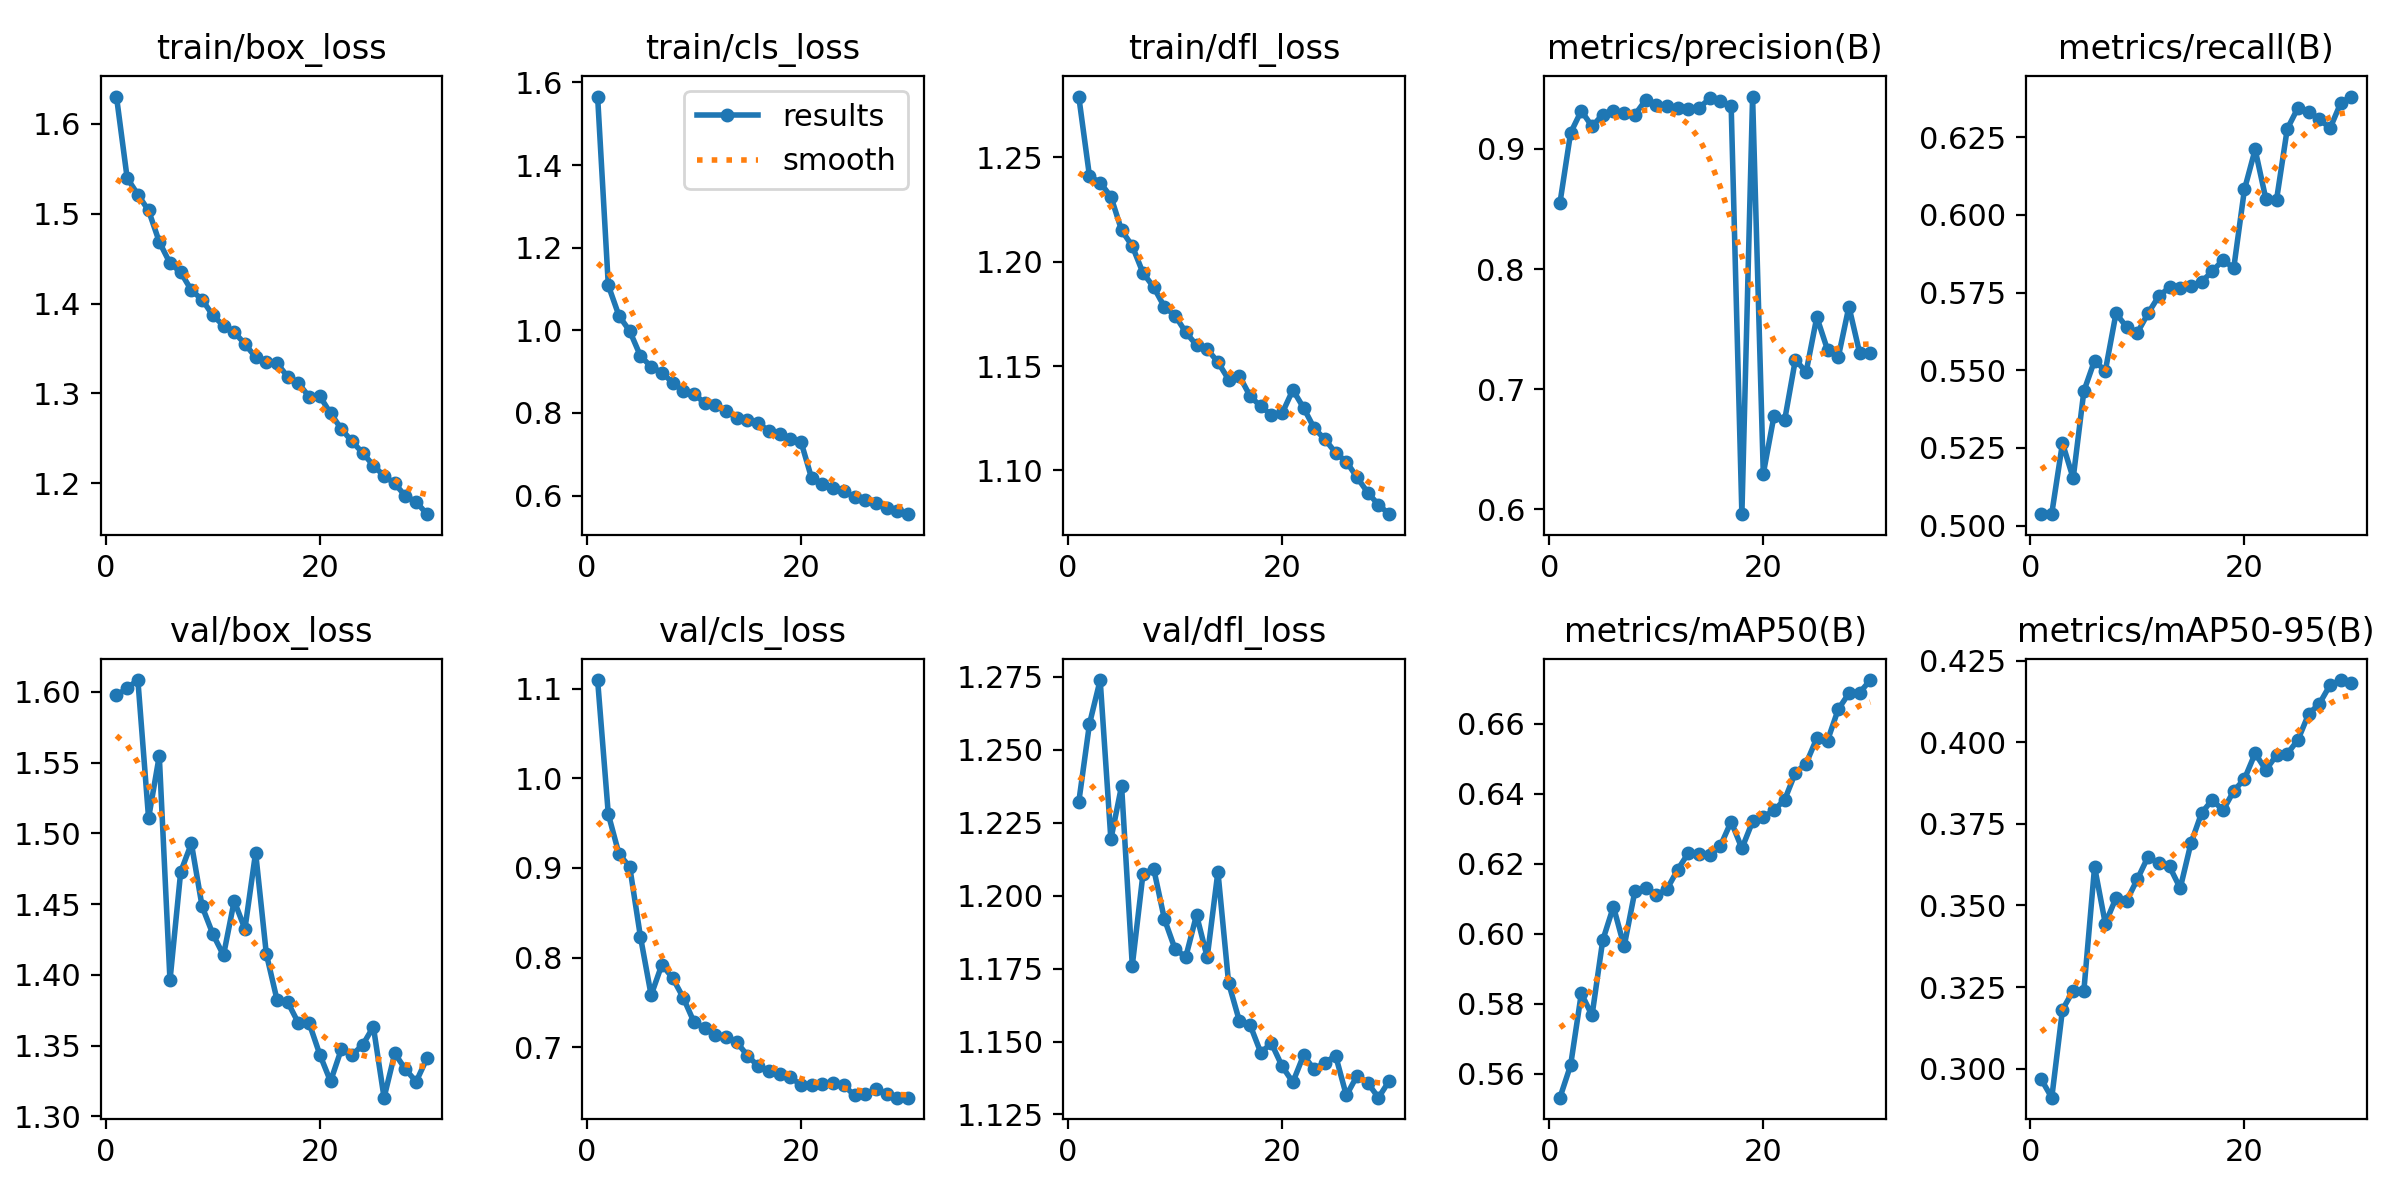

Mostrando: confusion_matrix.png


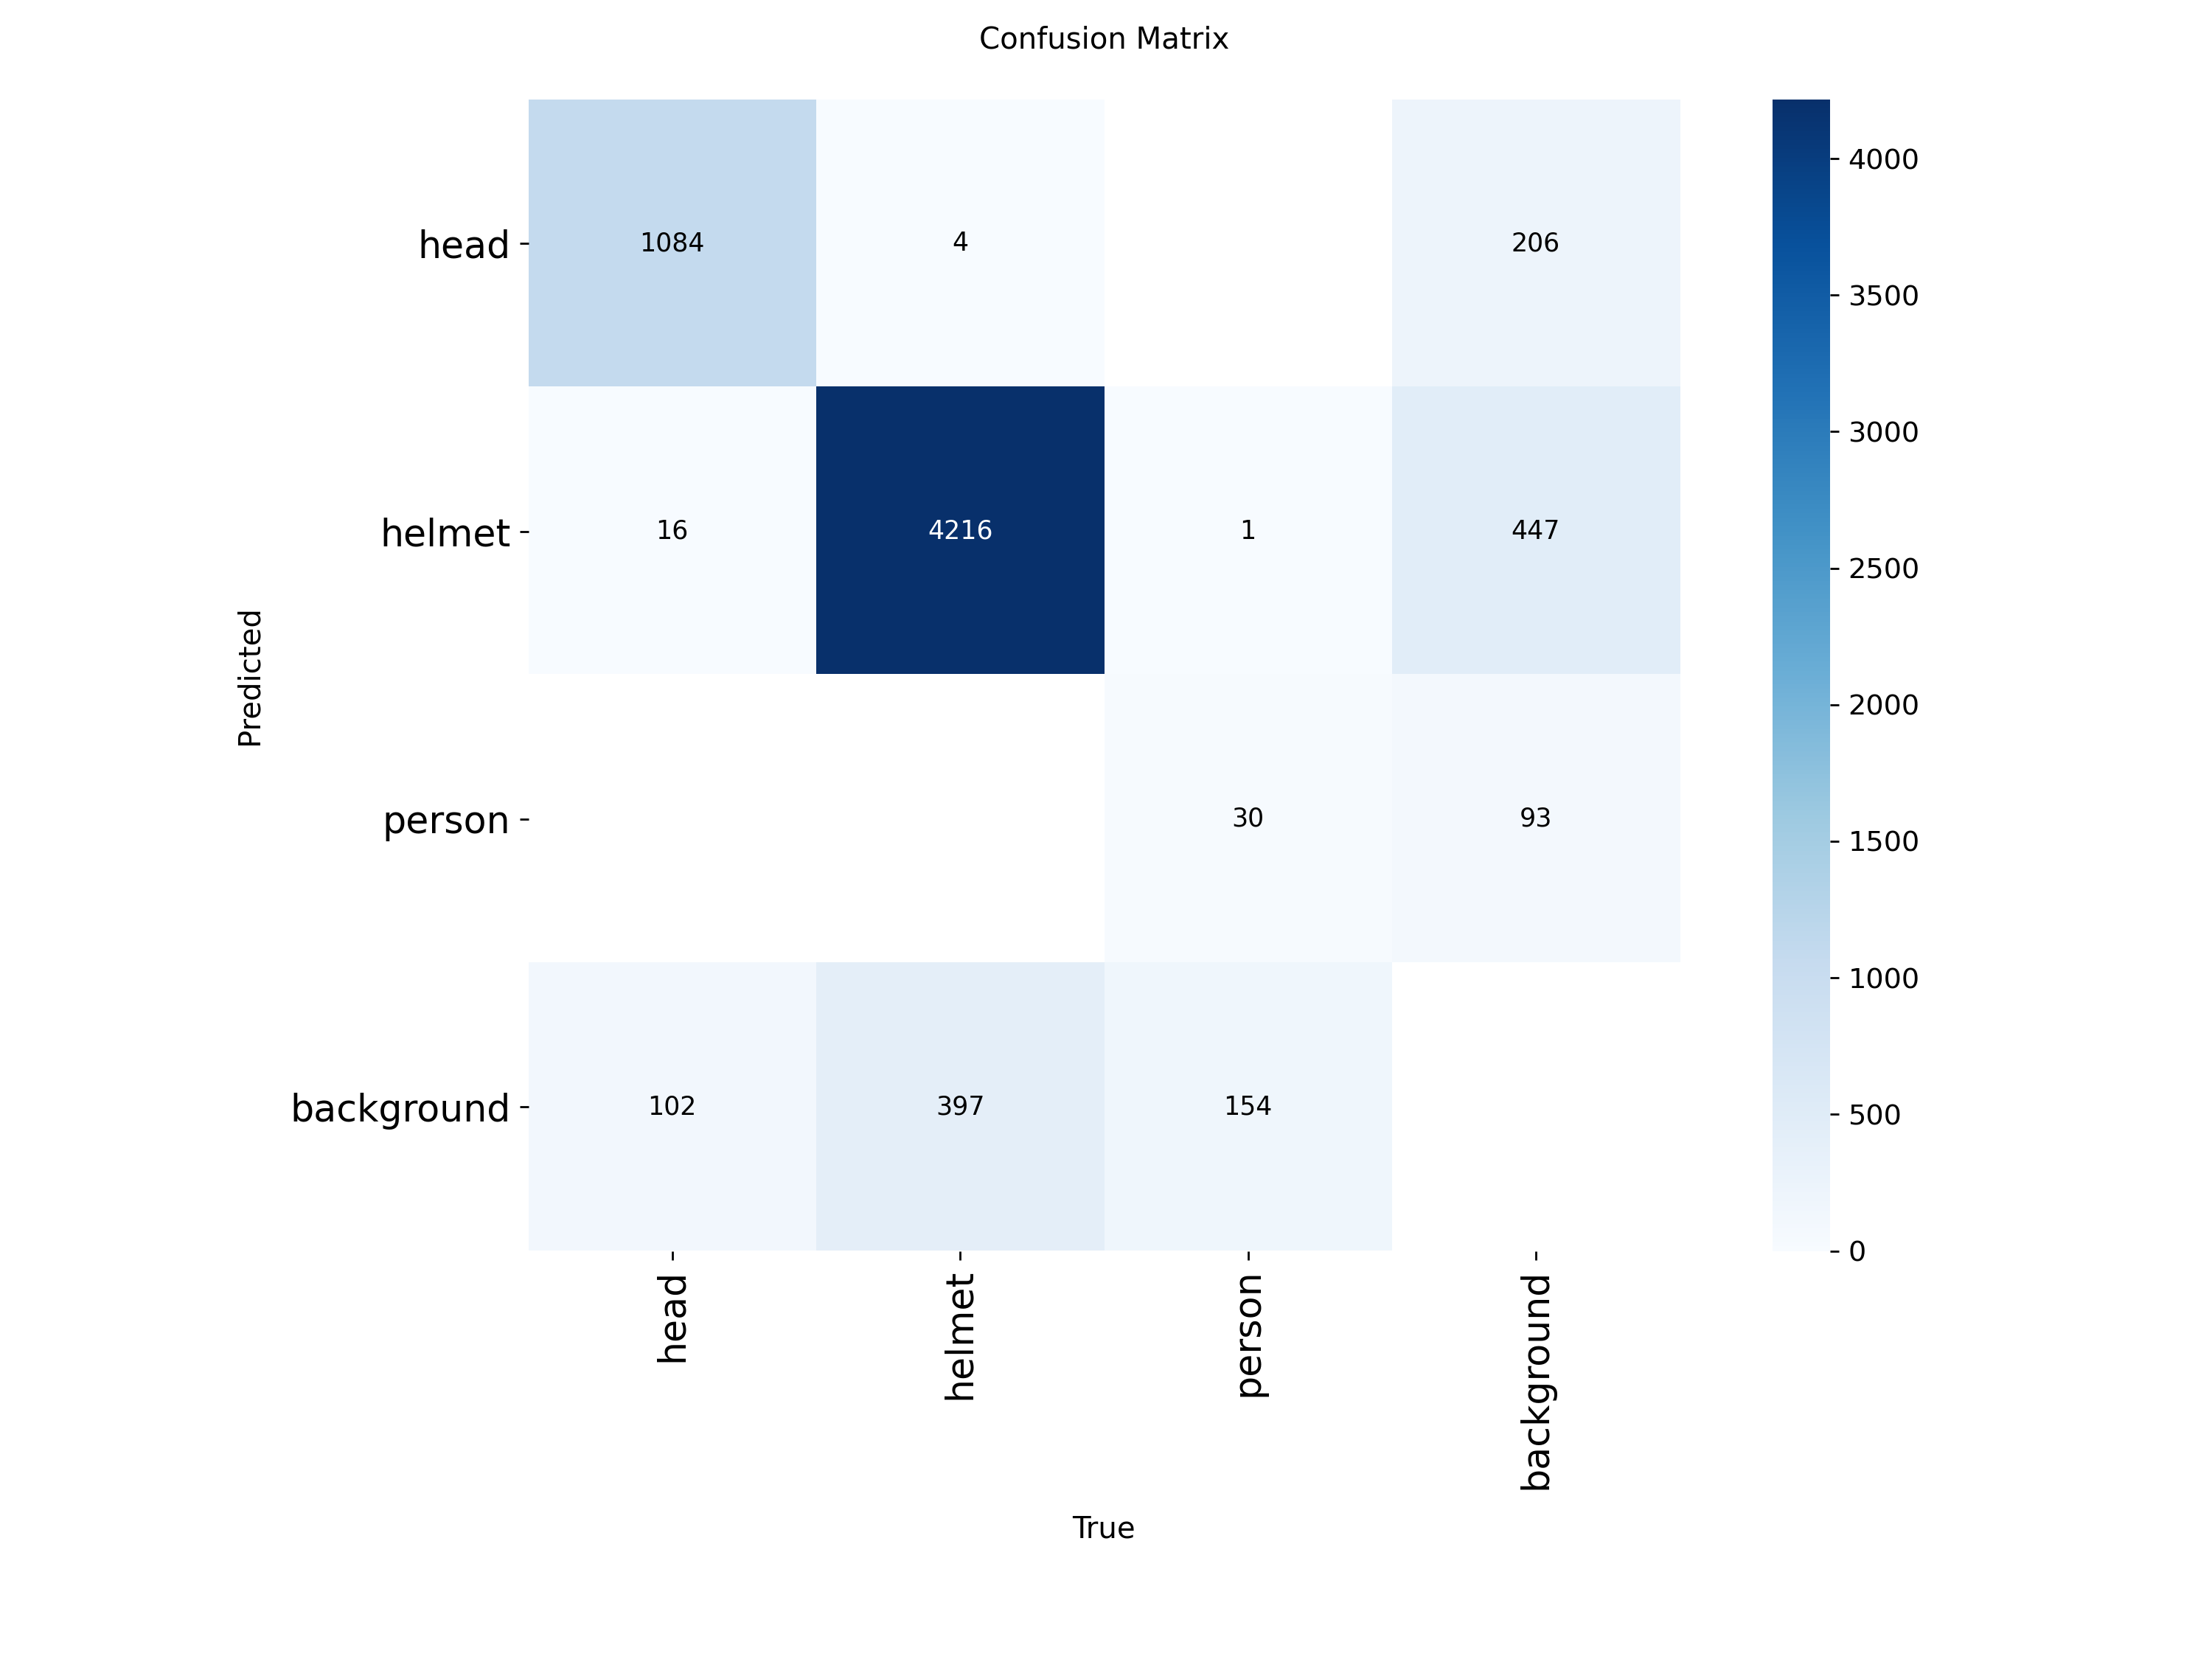

In [ ]:
# ============================================================
# VISUALIZAR GRÁFICAS DEL ENTRENAMIENTO
# ============================================================

from IPython.display import Image, display
import os

graficas_dir = "/content/proyecto_ppe_yolo/resultados/metricas/graficas_entrenamiento"

for archivo in ["results.png", "confusion_matrix.png"]:
    ruta = os.path.join(graficas_dir, archivo)

    if os.path.exists(ruta):
        print("Mostrando:", archivo)
        display(Image(filename=ruta, width=700))
    else:
        print("No encontrado:", archivo)